# Eksperimen 5: Full Model Training (AttentiveSkel-3D)

Notebook ini menjalankan **pelatihan skala penuh** model AttentiveSkel-3D menggunakan seluruh dataset video yang tersedia.

**Konfigurasi Full Training:**
* Dataset: seluruh tensor `.npy` di `data/processed/tensors/` (ratusan sampel)
* `batch_size=16`, `train_ratio=0.70`, `val_ratio=0.15`, `test_ratio=0.15`
* `num_epochs=100` (dengan Early Stopping otomatis jika model sudah konvergen)
* Loss function: `CrossEntropyLoss`
* Optimizer: `Adam (lr=0.001)`

**Target:**
* Model terbaik (val_loss terendah) tersimpan di `models/saved_models/best_model.pth` ✓
* Kurva learning diplot untuk analisis konvergensi ✓
* Inferensi batch validasi diverifikasi setelah pelatihan ✓

> ⏱ **Estimasi waktu:** Pelatihan dengan dataset penuh dan 100 epoch dapat memakan waktu
> yang cukup lama (puluhan menit hingga beberapa jam tergantung hardware).
> Gunakan GPU jika tersedia untuk mempercepat proses.


### 1. Import Library & Konfigurasi

In [4]:
# ============================================================
# Import semua library yang dibutuhkan untuk pelatihan
# ============================================================
import sys
import os
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Tambahkan direktori src/ ke Python path
sys.path.insert(0, os.path.abspath("../src"))

from models.model_3dcnn import AttentiveSkel3D, count_parameters
from data.dataset import create_dataloaders
from models.train import train_model

# Tentukan device — gunakan GPU jika tersedia
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Import berhasil.")
print(f"PyTorch versi : {torch.version}")
print(f"Device aktif  : {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU           : {torch.cuda.get_device_name(0)}")
    print(f"VRAM tersedia : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Import berhasil.
PyTorch versi : <module 'torch.version' from 'c:\\Users\\Administrator\\anaconda3\\envs\\attentiveskel\\lib\\site-packages\\torch\\version.py'>
Device aktif  : cuda
GPU           : NVIDIA GeForce RTX 3060 Ti
VRAM tersedia : 8.0 GB


### 2. Persiapan Direktori & Path

In [5]:
# ============================================================
# Definisi path dan persiapan direktori penyimpanan model
# ============================================================
MANIFEST_PATH = Path("../data/processed/dataset_manifest.csv")
SAVED_MODELS_DIR = Path("../models/saved_models")

# Buat folder saved_models jika belum ada
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)

print(f"Manifest CSV     : {MANIFEST_PATH.resolve()}")
print(f"Saved models dir : {SAVED_MODELS_DIR.resolve()}")

# Cek ketersediaan manifest
if not MANIFEST_PATH.exists():
    print("\n[PERINGATAN] Manifest CSV tidak ditemukan!")
    print("Jalankan terlebih dahulu notebook 04 atau script build_dataset.py.")
else:
    import pandas as pd
    df_manifest = pd.read_csv(MANIFEST_PATH)
    print(f"\n[OK] Manifest ditemukan: {len(df_manifest)} sampel total.")
    print(f"Distribusi: {df_manifest['label'].value_counts().to_dict()} (0=Benar, 1=Salah)")

Manifest CSV     : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\data\processed\dataset_manifest.csv
Saved models dir : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models

[OK] Manifest ditemukan: 487 sampel total.
Distribusi: {0: 303, 1: 184} (0=Benar, 1=Salah)


### 3. Buat DataLoader (Train / Validasi / Test)

Dataset dibagi dengan rasio **70% Train — 15% Validasi — 15% Test** menggunakan stratified split
agar distribusi kelas (Benar/Salah) tetap seimbang di setiap subset.
`batch_size=16` dipilih sebagai trade-off antara kecepatan training dan stabilitas gradient.


In [6]:
# ============================================================
# Buat DataLoader untuk Train, Validasi, dan Test.
# Rasio split: 70% Train | 15% Val | 15% Test
# batch_size=16 dipilih untuk efisiensi GPU dan stabilitas gradient.
# num_workers=0 direkomendasikan di Windows untuk menghindari masalah multiprocessing.
# ============================================================
train_loader, val_loader, test_loader = create_dataloaders(
    csv_file=MANIFEST_PATH,
    batch_size=16,
    train_ratio=0.70,   # 70% data untuk pelatihan
    val_ratio=0.15,     # 15% data untuk validasi (early stopping reference)
    # test_ratio Dihapus karena dihitung otomatis dari sisa (1.0 - 0.70 - 0.15 = 0.15)
    num_workers=0,      # 0 = tidak ada subprocess (aman di Windows)
    random_seed=42,     # Seed tetap untuk reproduksibilitas
)

print(f"DataLoader berhasil dibuat:")
print(f"  Train : {len(train_loader.dataset):>4} sampel  |  {len(train_loader):>3} batch per epoch  (batch_size=16)")
print(f"  Val   : {len(val_loader.dataset):>4} sampel  |  {len(val_loader):>3} batch per epoch")
print(f"  Test  : {len(test_loader.dataset):>4} sampel  |  {len(test_loader):>3} batch per epoch")
print(f"  Total : {len(train_loader.dataset) + len(val_loader.dataset) + len(test_loader.dataset):>4} sampel")

# Verifikasi shape satu batch dari train_loader
sample_batch, sample_labels = next(iter(train_loader))
print(f"\nVerifikasi shape batch:")
print(f"  Input  : {sample_batch.shape}  → (B=16, T=64, L=33, C=3)")
print(f"  Labels : {sample_labels.shape}  → (B=16,)  nilai unik: {sample_labels.unique().tolist()}")

Dataset split selesai (seed=42):
  Train  :  340 sampel → 21 batch
  Val    :   73 sampel → 5 batch
  Test   :   74 sampel → 5 batch
DataLoader berhasil dibuat:
  Train :  340 sampel  |   21 batch per epoch  (batch_size=16)
  Val   :   73 sampel  |    5 batch per epoch
  Test  :   74 sampel  |    5 batch per epoch
  Total :  487 sampel

Verifikasi shape batch:
  Input  : torch.Size([16, 64, 33, 3])  → (B=16, T=64, L=33, C=3)
  Labels : torch.Size([16])  → (B=16,)  nilai unik: [0, 1]


### 4. Inisialisasi Model, Loss, dan Optimizer

In [7]:
# ============================================================
# Inisialisasi model AttentiveSkel-3D
# ============================================================
model = AttentiveSkel3D(num_classes=2).to(DEVICE)
print(f"Model AttentiveSkel-3D berhasil diinisialisasi.")
print(f"  num_classes               : 2 (0=Benar, 1=Salah)")
print(f"  Total parameter trainable : {count_parameters(model):,}")
print(f"  Estimasi ukuran model     : {count_parameters(model) * 4 / 1024**2:.2f} MB")

Model AttentiveSkel-3D berhasil diinisialisasi.
  num_classes               : 2 (0=Benar, 1=Salah)
  Total parameter trainable : 101,891
  Estimasi ukuran model     : 0.39 MB


In [8]:
# ============================================================
# Inisialisasi loss function dan optimizer
# ============================================================

# CrossEntropyLoss: menggabungkan Softmax + NLLLoss,
# cocok untuk klasifikasi multi-kelas dengan logit mentah sebagai input
criterion = nn.CrossEntropyLoss()

# Adam optimizer: adaptif learning rate, konvergen lebih cepat dari SGD biasa
# lr=0.001 adalah nilai default yang umum digunakan sebagai titik awal
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Loss function : {criterion.__class__.__name__}")
print(f"Optimizer     : {optimizer.__class__.__name__} (lr=0.001)")

print(f"\nParameter optimizer:")
for pg in optimizer.param_groups:
    print(f"  lr={pg['lr']}, betas={pg['betas']}, eps={pg['eps']}, weight_decay={pg['weight_decay']}")

Loss function : CrossEntropyLoss
Optimizer     : Adam (lr=0.001)

Parameter optimizer:
  lr=0.001, betas=(0.9, 0.999), eps=1e-08, weight_decay=0


### 5. Jalankan Full Training Loop (maks. 100 Epoch + Early Stopping)

> ⏱ **Peringatan:** Pelatihan dengan dataset penuh akan memakan waktu yang signifikan.
> Monitor log per-epoch di output cell ini. Model terbaik akan otomatis disimpan ke
> `../models/saved_models/best_model.pth` setiap kali `val_loss` mencapai nilai minimum baru.


In [9]:

# ============================================================
# Full Training Loop — maksimum 100 epoch.
#
# Catatan penting:
#   - train.py sudah menerapkan early stopping berbasis val_loss:
#     pelatihan akan berhenti otomatis jika val_loss tidak membaik
#     dalam sejumlah epoch berturut-turut (patience di train.py).
#   - Checkpoint best_model.pth diperbarui setiap kali val_loss
#     mencapai nilai minimum baru — bahkan jika training dihentikan
#     lebih awal, bobot terbaik tetap terjaga.
#   - Gunakan GPU untuk mempercepat proses (DEVICE terdeteksi otomatis
#     di cell 1 — tampilkan CUDA jika GPU tersedia).
#   - Direktori simpan: ../models/saved_models/best_model.pth
# ============================================================

NUM_EPOCHS = 100   # Jumlah epoch maksimum — early stopping akan hentikan lebih awal jika konvergen

print(f"Memulai Full Training — maks. {NUM_EPOCHS} epoch")
print(f"  Device            : {DEVICE}")
print(f"  Sampel train      : {len(train_loader.dataset)}")
print(f"  Sampel val        : {len(val_loader.dataset)}")
print(f"  Batch per epoch   : {len(train_loader)} (train)  /  {len(val_loader)} (val)")
print(f"  Checkpoint simpan : {(SAVED_MODELS_DIR / 'best_model.pth').resolve()}")
print()

history = train_model(
    model         = model,
    train_loader  = train_loader,
    val_loader    = val_loader,
    criterion     = criterion,
    optimizer     = optimizer,
    num_epochs    = NUM_EPOCHS,
    device        = DEVICE,
    save_dir      = SAVED_MODELS_DIR,
    save_filename = "best_model.pth",
    verbose       = True,
)

print(f"\nPelatihan selesai.")
print(f"  Best epoch      : {history.get('best_epoch', '-')}")
print(f"  Best val loss   : {history.get('best_val_loss', 0):.4f}")


Memulai Full Training — maks. 100 epoch
  Device            : cuda
  Sampel train      : 340
  Sampel val        : 73
  Batch per epoch   : 21 (train)  /  5 (val)
  Checkpoint simpan : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\best_model.pth

  Memulai pelatihan AttentiveSkel-3D
  Device    : cuda
  Epochs    : 100
  Save path : ..\models\saved_models\best_model.pth
Epoch [  1/100] ✓ | Train Loss: 0.5199 | Train Acc:  79.46% | Val Loss: 0.4596 | Val Acc:  82.19% | Waktu: 4.0s
Epoch [  2/100] ✓ | Train Loss: 0.3794 | Train Acc:  85.42% | Val Loss: 0.3980 | Val Acc:  80.82% | Waktu: 0.3s
Epoch [  3/100]   | Train Loss: 0.3456 | Train Acc:  88.69% | Val Loss: 0.4515 | Val Acc:  78.08% | Waktu: 0.3s
Epoch [  4/100] ✓ | Train Loss: 0.3274 | Train Acc:  86.61% | Val Loss: 0.3353 | Val Acc:  89.04% | Waktu: 0.3s
Epoch [  5/100]   | Train Loss: 0.2575 | Train Acc:  88.10% | Val Loss: 0.3476 | Val Acc:  86.30% | Waktu: 0.3s
Epoch [  6/100]   | Train L

### 6. Verifikasi File Model Tersimpan

In [10]:
# ============================================================
# Pastikan file best_model.pth berhasil disimpan dan isinya valid.
# ============================================================
best_model_path = SAVED_MODELS_DIR / "best_model.pth"

if best_model_path.exists():
    checkpoint = torch.load(best_model_path, map_location=DEVICE)
    file_size_kb = best_model_path.stat().st_size / 1024
    print(f"[OK] File model tersimpan: {best_model_path}")
    print(f"     Ukuran file          : {file_size_kb:.1f} KB")
    print(f"     Disimpan pada epoch  : {checkpoint.get('epoch', 'N/A')}")
    print(f"     Val Loss terbaik     : {checkpoint.get('val_loss', 0):.4f}")
    
    # Amankan dari KeyError jika 'val_acc' tidak disimpan oleh agent
    val_acc = checkpoint.get('val_acc', 0)
    print(f"     Val Acc terbaik      : {val_acc*100:.2f}%")
else:
    print("[PERINGATAN] File best_model.pth tidak ditemukan.")
    print("  Kemungkinan val_loss tidak pernah turun. Periksa konfigurasi pelatihan.")

[OK] File model tersimpan: ..\models\saved_models\best_model.pth
     Ukuran file          : 1215.7 KB
     Disimpan pada epoch  : 47
     Val Loss terbaik     : 0.1559
     Val Acc terbaik      : 97.26%


C:\Users\Administrator\AppData\Local\Temp\ipykernel_2264\1697482677.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_model_path, map_location

### 7. Visualisasi: Kurva Learning

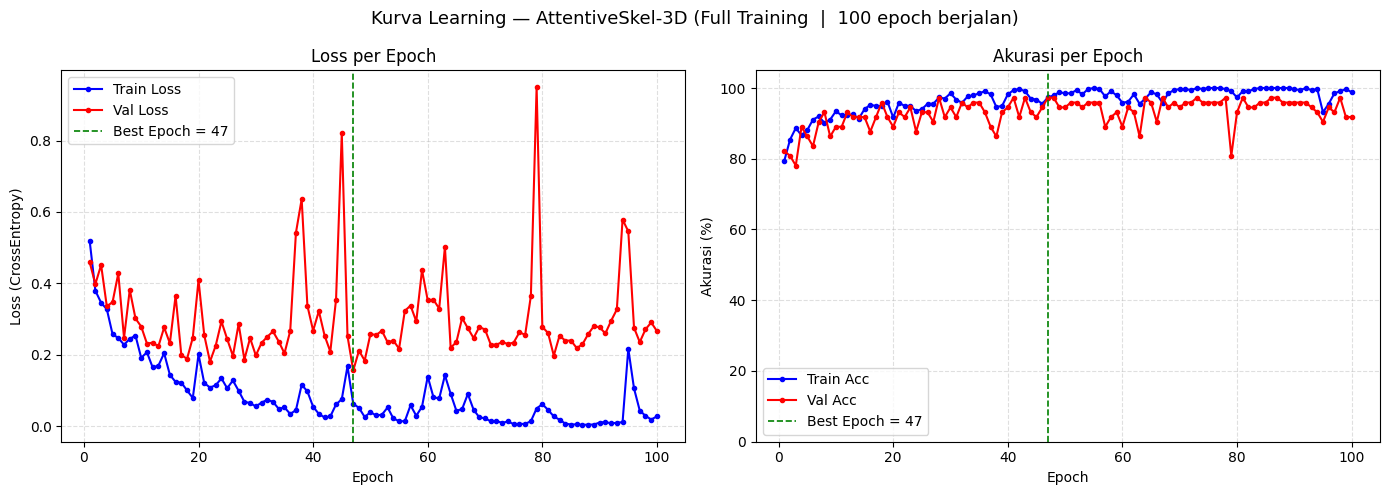


Ringkasan hasil Full Training:
  Epoch berjalan   : 100  (maks. dikonfigurasi: 100)
  Train Loss akhir : 0.0273
  Val Loss akhir   : 0.2660
  Train Acc akhir  : 98.81%
  Val Acc akhir    : 91.78%
  Best Epoch       : 47  (Val Loss = 0.1559)
  Checkpoint       : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\models\saved_models\best_model.pth


In [11]:

# ============================================================
# Plot kurva loss dan akurasi training vs validasi per epoch.
# Digunakan untuk mendeteksi overfitting, underfitting, dan
# menentukan epoch optimal berdasarkan val_loss terbaik.
# ============================================================
actual_epochs = len(history["train_loss"])   # Bisa < NUM_EPOCHS jika early stopping aktif
epochs = range(1, actual_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Kurva Learning — AttentiveSkel-3D (Full Training  |  {actual_epochs} epoch berjalan)",
    fontsize=13,
)

# ── Panel kiri: Loss ──────────────────────────────────────────────────────────
ax_loss = axes[0]
ax_loss.plot(epochs, history["train_loss"], "b-o", markersize=3, label="Train Loss")
ax_loss.plot(epochs, history["val_loss"],   "r-o", markersize=3, label="Val Loss")
ax_loss.axvline(
    x     = history.get("best_epoch", 1),
    color = "green", linestyle = "--", linewidth = 1.2,
    label = f"Best Epoch = {history.get('best_epoch', 1)}",
)
ax_loss.set_title("Loss per Epoch")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss (CrossEntropy)")
ax_loss.legend()
ax_loss.grid(True, linestyle="--", alpha=0.4)

# ── Panel kanan: Akurasi ──────────────────────────────────────────────────────
ax_acc = axes[1]
ax_acc.plot(epochs, [a * 100 for a in history["train_acc"]], "b-o", markersize=3, label="Train Acc")
ax_acc.plot(epochs, [a * 100 for a in history["val_acc"]],   "r-o", markersize=3, label="Val Acc")
ax_acc.axvline(
    x     = history.get("best_epoch", 1),
    color = "green", linestyle = "--", linewidth = 1.2,
    label = f"Best Epoch = {history.get('best_epoch', 1)}",
)
ax_acc.set_title("Akurasi per Epoch")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Akurasi (%)")
ax_acc.set_ylim(0, 105)
ax_acc.legend()
ax_acc.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# ── Ringkasan metrik akhir ─────────────────────────────────────────────────────
print(f"\nRingkasan hasil Full Training:")
print(f"  Epoch berjalan   : {actual_epochs}  (maks. dikonfigurasi: {NUM_EPOCHS})")
print(f"  Train Loss akhir : {history['train_loss'][-1]:.4f}")
print(f"  Val Loss akhir   : {history['val_loss'][-1]:.4f}")
print(f"  Train Acc akhir  : {history['train_acc'][-1]*100:.2f}%")
print(f"  Val Acc akhir    : {history['val_acc'][-1]*100:.2f}%")
print(f"  Best Epoch       : {history.get('best_epoch', 1)}  "
      f"(Val Loss = {history.get('best_val_loss', 0):.4f})")
print(f"  Checkpoint       : {(SAVED_MODELS_DIR / 'best_model.pth').resolve()}")


### 8. Uji Inferensi: Load Model Terbaik & Prediksi Satu Batch

In [12]:
# ============================================================
# Muat model terbaik dari disk dan jalankan inferensi
# pada satu batch validasi untuk memastikan pipeline
# load → predict berjalan dengan benar.
# ============================================================
# Buat instance model baru (simulasi deployment)
model_loaded = AttentiveSkel3D(num_classes=2).to(DEVICE)

# Muat bobot dari checkpoint
checkpoint = torch.load(SAVED_MODELS_DIR / "best_model.pth", map_location=DEVICE)
model_loaded.load_state_dict(checkpoint["model_state_dict"])
model_loaded.eval()

print(f"Model terbaik berhasil dimuat dari epoch {checkpoint.get('epoch', 'N/A')}.")

# Ambil satu batch dari val_loader dan jalankan inferensi
with torch.no_grad():
    val_batch, val_labels = next(iter(val_loader))
    val_batch = val_batch.to(DEVICE)
    val_labels = val_labels.to(DEVICE)
    
    # Forward pass
    logits = model_loaded(val_batch)
    probs = torch.softmax(logits, dim=1)
    predictions = torch.argmax(probs, dim=1)

label_map = {0: "Benar", 1: "Salah"}

print(f"\nHasil inferensi pada {val_batch.size(0)} sampel val:")
print(f"{'Sampel':>8} {'Label Asli':>12} {'Prediksi':>10} {'P(Benar)':>10} {'P(Salah)':>10} {'Status':>8}")
print("-" * 64)

for i in range(val_batch.size(0)):
    true_lbl = val_labels[i].item()
    pred_lbl = predictions[i].item()
    p_benar = probs[i, 0].item()
    p_salah = probs[i, 1].item()
    
    status = "BENAR" if true_lbl == pred_lbl else "SALAH"
    print(
        f"{i:>8} {label_map[true_lbl]:>12} {label_map[pred_lbl]:>10} "
        f"{p_benar:>10.4f} {p_salah:>10.4f} {status:>8}"
    )

Model terbaik berhasil dimuat dari epoch 47.

Hasil inferensi pada 16 sampel val:
  Sampel   Label Asli   Prediksi   P(Benar)   P(Salah)   Status
----------------------------------------------------------------
       0        Benar      Benar     1.0000     0.0000    BENAR
       1        Benar      Benar     0.9537     0.0463    BENAR
       2        Benar      Benar     1.0000     0.0000    BENAR
       3        Salah      Salah     0.0001     0.9999    BENAR
       4        Benar      Benar     0.9999     0.0001    BENAR
       5        Benar      Benar     1.0000     0.0000    BENAR
       6        Benar      Benar     1.0000     0.0000    BENAR
       7        Benar      Benar     1.0000     0.0000    BENAR
       8        Salah      Salah     0.0002     0.9998    BENAR
       9        Salah      Salah     0.3291     0.6709    BENAR
      10        Salah      Salah     0.0000     1.0000    BENAR
      11        Salah      Salah     0.0055     0.9945    BENAR
      12        Salah

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2264\3751426113.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(SAVED_MODELS_DIR / "best_mod